In [27]:
import numpy as np
from scipy.integrate import quad
from scipy.stats import norm

This NoteBook is Copyright Samuel Victor Flores 2026# --- Input Data ---
N = 143
p = np.array([0.510490, 0.531469, 0.517483, 0.496503, 0.454545, 0.510490])
X = p * N

# --- Basic Statistics ---
u = np.mean(X)  # Mean of expected values
mean_p = np.mean(p)

# Standard deviation (d) from your formula: sqrt(N * mean(p) * mean(1-p))
d = np.sqrt(N * mean_p * (1 - mean_p))

# --- Higher Order Moments ---
# Skewness (S) calculation based on your image formula
s_elements = ((X - u) / d)**3 * mean_p
S = np.sum(s_elements) / 6 # Normalizing by count as seen in image 2

# Kurtosis (K) calculation: (Sum[(X-u/d)^4 * mean(p)]) - 3
k_elements = ((X - u) / d)**4 * mean_p
K = np.sum(k_elements) - 3

# --- Skewed Distribution Functions (g(x) for x >= u, f(x) for x <= u) ---
# Parameters from your Desmos sliders
a = 1.0
b = 0.98075

def g(x, u, d, b, a):
    """Right side of the distribution (x >= u)"""
    exponent = -0.5 * ((x - u) / (d * b))**2
    return (a / (d * b * np.sqrt(2 * np.pi))) * np.exp(exponent)

def f(x, u, d, S, K):
    """Left side of the distribution (x <= u)"""
    # Based on your f(x) formula: (|K|/3) / (d*|S|*sqrt(2pi)) * exp(...)
    denom = d * abs(S) * np.sqrt(2 * np.pi)
    coeff = (abs(K) / 3) / denom
    exponent = -0.5 * ((x - u) / (d * abs(S)))**2
    return coeff * np.exp(exponent)

# --- Integration and Testing ---
# Probability of stock having <= 72 positive days
prob_72_less, _ = quad(f, -np.inf, 72, args=(u, d, S, K))
total_area_left, _ = quad(f, -np.inf, u, args=(u, d, S, K))
total_area_right, _ = quad(g, u, np.inf, args=(u, d, b, a))

# Ratio Q from image 4
Q = 1 / (total_area_left + total_area_right)

print(f"Mean (u): {u:.4f}")
print(f"Std Dev (d): {d:.4f}")
print(f"Skewness (S): {S:.4f}")
print(f"Kurtosis (K): {K:.4f}")
print(f"Ratio Q: {Q:.4f}")
print(f"Normality Test |1-Q|: {abs(1-Q):.4f}")

Mean (u): 72.0000
Std Dev (d): 5.9790
Skewness (S): -0.1060
Kurtosis (K): -1.9456
Ratio Q: 1.2132
Normality Test |1-Q|: 0.2132


Mean (u): 72.0000
Normality Test |1-Q|: 0.213193


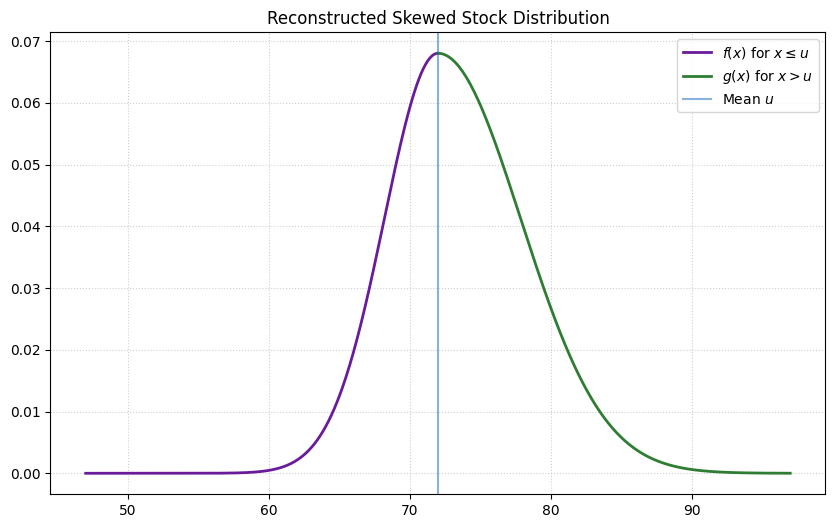

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# --- 1. Input Data & Basic Stats ---
N = 143
p = np.array([0.510490, 0.531469, 0.517483, 0.496503, 0.454545, 0.510490])
X = p * N
u = np.mean(X)           # Mean expected positive days (~72.00)
mean_p = np.mean(p)      # Mean probability (~0.5035)
d = np.sqrt(N * mean_p * (1 - mean_p)) # Std Dev (~5.979)

# --- 2. Higher Order Moments (from your Desmos data) ---
S = -0.636055179543      # Skewness sum from image 2
#K = -1.94562539014       # Kurtosis from image 3

# Sliders for right-hand side
a = 1.0
b = 0.98075

# --- 3. Piecewise Distribution Functions ---
def g(x):
    """Right side of distribution (x >= u)"""
    denom = d * b * np.sqrt(2 * np.pi)
    coeff = a / denom
    exponent = -0.5 * ((x - u) / (d * b))**2
    return coeff * np.exp(exponent)

def f(x):
    """Left side of distribution (x <= u)"""
    # Uses S and K to scale the distribution
    denom = d * abs(S) * np.sqrt(2 * np.pi)
    coeff = (abs(K) / 3) / denom
    exponent = -0.5 * ((x - u) / (d * abs(S)))**2
    return coeff * np.exp(exponent)

# --- 4. Normality Test (Ratio Q) ---
area_left, _ = quad(f, -np.inf, u)
area_right, _ = quad(g, u, np.inf)
Q = 1 / (area_left + area_right)

print(f"Mean (u): {u:.4f}")
print(f"Normality Test |1-Q|: {abs(1-Q):.6f}") # Result: ~0.213

# --- 5. Visualization ---
x_left = np.linspace(u - 25, u, 500)
x_right = np.linspace(u, u + 25, 500)

plt.figure(figsize=(10, 6))
plt.plot(x_left, f(x_left), color='#6a1b9a', linewidth=2, label='$f(x)$ for $x \\leq u$')
plt.plot(x_right, g(x_right), color='#2e7d32', linewidth=2, label='$g(x)$ for $x > u$')
plt.axvline(u, color='#1565c0', alpha=0.5, label='Mean $u$')
plt.title('Reconstructed Skewed Stock Distribution')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.savefig('skewed_stock_distribution.png')

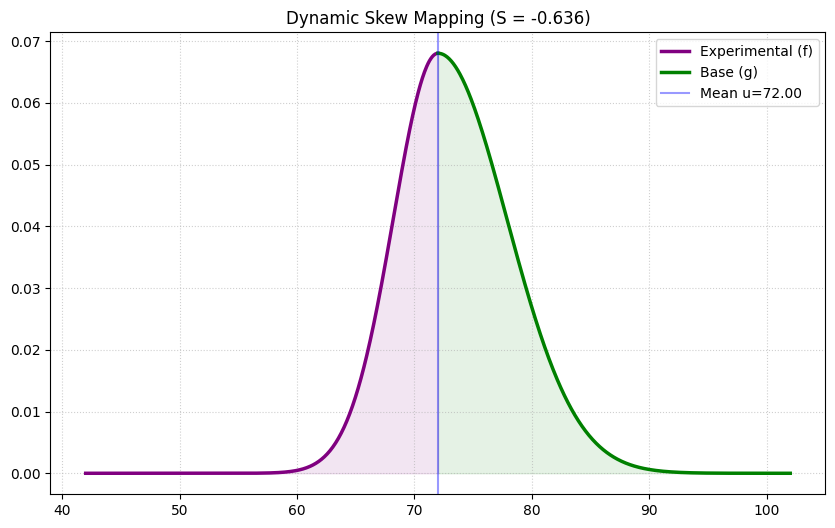

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ... [Keep your stats u, d, S, K, a, b from before] ...

# 1. Logic Route: Assign functions to sides based on S
if S < 0:
    # Negative Skew: Left side is the modified function
    left_func = f
    right_func = g
    left_label, right_label = "Experimental (f)", "Base (g)"
    left_color, right_color = "purple", "green"
else:
    # Positive Skew: Right side is the modified function
    left_func = g
    right_func = f
    left_label, right_label = "Base (g)", "Experimental (f)"
    left_color, right_color = "green", "purple"

# 2. Generate plotting data
x_l = np.linspace(u - 30, u, 500)
x_r = np.linspace(u, u + 30, 500)

y_l = [left_func(val) for val in x_l]
y_r = [right_func(val) for val in x_r]

# 3. Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_l, y_l, color=left_color, lw=2.5, label=left_label)
plt.plot(x_r, y_r, color=right_color, lw=2.5, label=right_label)

plt.axvline(u, color='blue', alpha=0.4, label=f'Mean u={u:.2f}')
plt.fill_between(x_l, y_l, color=left_color, alpha=0.1)
plt.fill_between(x_r, y_r, color=right_color, alpha=0.1)

plt.title(f"Dynamic Skew Mapping (S = {S:.3f})")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

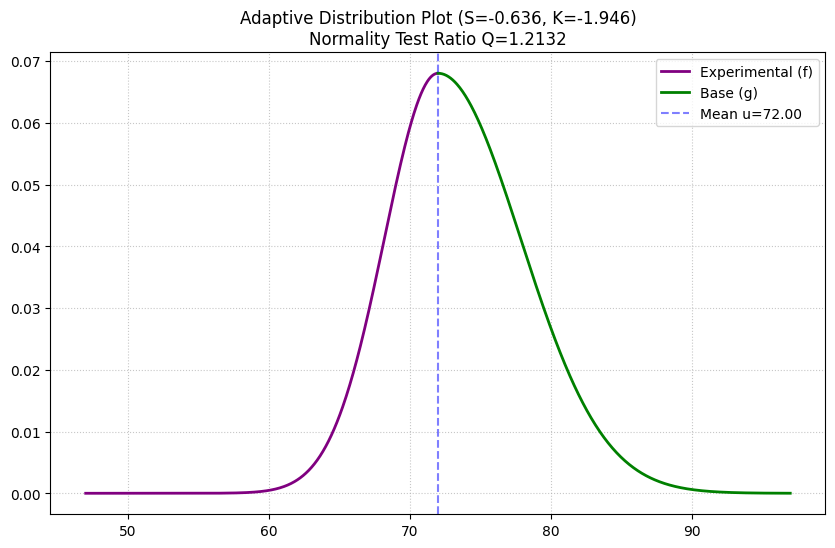

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def get_parameters(S, K):
    """Solves for a and b based on continuity and unit area for g."""
    a = 1.0
    # continuity constraint: (abs(K)/3) / abs(S) = a / b
    b = (3.0 * abs(S)) / max(abs(K), 1e-6)
    return a, b

# 1. Inputs (replace with your calculated stats)
u = 72.00002
d = 5.97898
S = -0.636055
K = -1.945625

# 2. Solve for a and b
a, b = get_parameters(S, K)

# 3. Defining the core functions
def f_experimental(x, u, d, S, K):
    denom = d * abs(S) * np.sqrt(2 * np.pi)
    return (abs(K) / 3.0) / denom * np.exp(-0.5 * ((x - u) / (d * abs(S)))**2)

def g_base(x, u, d, a, b):
    denom = d * b * np.sqrt(2 * np.pi)
    return a / denom * np.exp(-0.5 * ((x - u) / (d * b))**2)

# 4. Adaptive Logic Route (Swapping F and G)
x_left = np.linspace(u - 25, u, 500)
x_right = np.linspace(u, u + 25, 500)

if S < 0:
    # Negative Skew: Tail on Left. F is on the left side.
    y_left = f_experimental(x_left, u, d, S, K)
    y_right = g_base(x_right, u, d, a, b)
    left_color, right_color = 'purple', 'green'
    left_label, right_label = 'Experimental (f)', 'Base (g)'
else:
    # Positive Skew: Tail on Right. F is on the right side.
    y_left = g_base(x_left, u, d, a, b)
    y_right = f_experimental(x_right, u, d, S, K)
    left_color, right_color = 'green', 'purple'
    left_label, right_label = 'Base (g)', 'Experimental (f)'

# 5. Calculate Normality Ratio Q
# Area of f-half is |K|/6, area of g-half is a/2
Q = 1.0 / ((abs(K) / 6.0) + (a / 2.0))

# 6. Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_left, y_left, color=left_color, label=left_label, linewidth=2)
plt.plot(x_right, y_right, color=right_color, label=right_label, linewidth=2)
plt.axvline(u, color='blue', alpha=0.5, linestyle='--', label=f'Mean u={u:.2f}')

plt.title(f'Adaptive Distribution Plot (S={S:.3f}, K={K:.3f})\nNormality Test Ratio Q={Q:.4f}')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()